# 04 — Validação (`validation`)

Origem: script 13.

## Estrutura

| Função | Papel |
|---|---|
| `make_splits(df, seeds, train_proportion, mode, external_valid_samples, n_samples)` | gera `(semente, treino, validação)` |
| `evaluate_split(train, test, classes, distribution, ENL, aggregation, rename_predicted, normalize)` | avalia **uma** divisão: `fit_model` → `classify` → matriz → agregação → métricas |
| `cross_validation(...)` | percorre as divisões e organiza os resultados |
| `select_seeds(results, rank_by)` | sementes de melhor, mediana e 3º quartil |
| `reproduce_iteration(df, classes, seed, ...)` | refaz exatamente uma iteração (modelo, previsão, matriz) |
| `cross_validation_stats(results)` | média, DP e intervalo empírico de 95% |

<details><summary><b>Correções em relação ao R</b></summary>

| Ponto | R original | Python |
|---|---|---|
| Seeds informadas | `ifelse` usava só `seed[1]` em todas as iterações | uma semente por iteração |
| Sementes retornadas | melhor = índice; mediana/Q3 = semente | todas são sementes |
| Classe sem referência | NaN em todas as métricas | excluída, com aviso |
| F1 com PA = UA = 0 | NaN | 0 |
| `type='fixed'` sem validação externa | erro obscuro | erro explícito |
</details>

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))   # pasta que contém sar_classification

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sar_classification import (distributions as dist, samples as smp, models as mdl,
                                raster_io as rio, separability as sep, validation as val,
                                fitting as fit, plots, diagnostics as diag)

In [2]:
# Dados fictícios gerados pelo próprio catálogo (substitua pelos seus df_samples)
rng = np.random.default_rng(42)
classes = ['F', 'VS', 'PA', 'SE']

def simulate(distribution, params_by_class, n, columns, ENL=None):
    parts = [pd.DataFrame(dist.get_distribution(distribution)['sample'](n, p, ENL, rng), columns=columns).assign(Class=c)
             for c, p in params_by_class.items()]
    return pd.concat(parts, ignore_index=True)[['Class'] + columns]

def random_cov(scale):
    A = rng.normal(0, scale, (3, 3))
    return A @ A.T + 1e-4 * np.eye(3)

df_gauss = simulate('gaussian', {c: {'mean': np.array(m), 'covariance_matrix': random_cov(0.02)} for c, m in
                    {'F': [0.20, 0.05, 0.30], 'VS': [0.22, 0.07, 0.28], 'PA': [0.10, 0.15, 0.20], 'SE': [0.05, 0.25, 0.10]}.items()},
                    120, ['B1', 'B2', 'B3'])
df_gamma = simulate('gamma', {c: {'alpha': 3.0, 'beta': 3.0 / mu} for c, mu in
                    {'F': 0.08, 'VS': 0.06, 'PA': 0.03, 'SE': 0.015}.items()}, 150, ['HH'], ENL=3)
df_pair = simulate('intensity_joint_distribution', {c: {'mu1': a, 'mu2': b, 'ro2': r} for c, (a, b, r) in
                   {'F': (0.08, 0.020, 0.25), 'VS': (0.06, 0.012, 0.16), 'PA': (0.03, 0.006, 0.09), 'SE': (0.015, 0.004, 0.49)}.items()},
                   150, ['HH', 'HV'], ENL=4)
print(df_gauss.shape, df_gamma.shape, df_pair.shape)

(480, 4) (600, 2) (600, 3)


## 1. Matriz de confusão e métricas

`confusion_matrix_table` monta a matriz com linhas = `Prediction` e colunas = `Reference`.

`metrics_calculation(cm, normalize=True)`:

| Métrica | `normalize=True` (original) | `normalize=False` |
|---|---|---|
| PA | $n_{jj}/n_{+j}$ | idem |
| UA | sobre a matriz com colunas normalizadas (referências equiprováveis) | $n_{ii}/n_{i+}$ |
| OA | $\frac{1}{K}\sum_j n_{jj}/n_{+j}$ = **acurácia balanceada** | $\sum n_{jj}/n$ |

> ⚠️ Se as tabelas da dissertação usaram `normalize=True`, a "Acurácia Global" reportada é a acurácia balanceada. Os valores estão corretos, mas a definição deve constar no texto.

> ⚠️ `rename_predicted` (antigo `fill_names`) renomeia **apenas a previsão**, como no original.

OA balanceada = 0.9028 | OA convencional = 0.9028


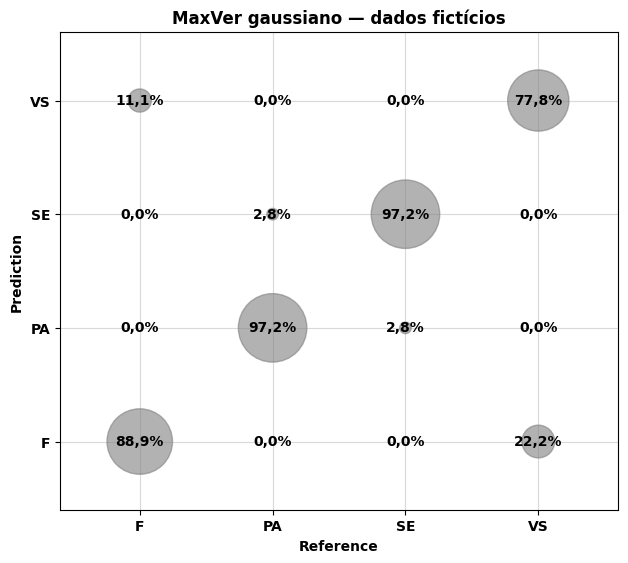

Reference,PA,SE,F+VS
Prediction,,,
PA,35,1,0
SE,1,35,0
F+VS,0,0,72


In [3]:
train, valid = smp.split_samples(df_gauss, ratio=0.7, random_state=1)
out = val.evaluate_split(train, valid, classes, 'gaussian')
print(f"OA balanceada = {out['overall_accuracy']:.4f} | "
      f"OA convencional = {val.metrics_calculation(out['confusion_matrix'], normalize=False)['overall_accuracy']:.4f}")
plots.bubble_confusion_plot(out['confusion_matrix'], title='MaxVer gaussiano — dados fictícios')
val.aggregate_classes(out['confusion_matrix'], ['F', 'VS'])

## 2. Validação cruzada

| Parâmetro | Padrão | Descrição |
|---|---|---|
| `distribution`, `ENL` | `'gaussian'`, `None` | modelo do catálogo |
| `n_iterations` / `seeds` | `10` / `None` | `None` → sementes 1..n |
| `train_proportion` | `0.7` | proporção de treino por classe |
| `mode` | `'variable'` | `'fixed'`: treino = 100%; validação vem de `external_valid_samples` |
| `external_valid_samples`, `n_samples` | `None` | validação independente; nº fixo por classe |
| `aggregation` | `None` | ex.: `[['F', 'VS']]`, aplicado à matriz de cada iteração |
| `normalize` | `True` | ver Seção 1 |
| `rank_by` | `'f1_macro'` | métrica que ordena as iterações em `select_seeds` |
| `keep_confusion_matrices` | `False` | guarda a matriz de cada iteração |

**Critério das sementes:** o script 13 ordena pelo **F1 macro**, enquanto a Seção 4.3.1.4 da dissertação descreve o 3º quartil da **Acurácia Global**. As duas opções estão disponíveis em `rank_by`. O padrão reproduz o código.

In [4]:
cv = val.cross_validation(df_gauss, classes, 'gaussian', n_iterations=20, verbose=False,
                          keep_confusion_matrices=True)
print('rank_by = f1_macro        :', cv['selected'])
print('rank_by = overall_accuracy:', val.select_seeds(cv, 'overall_accuracy'))

rank_by = f1_macro        : {'rank_by': 'f1_macro', 'best_seed': 20, 'median_seed': 17, 'third_quartile_seed': 6}
rank_by = overall_accuracy: {'rank_by': 'overall_accuracy', 'best_seed': 18, 'median_seed': 16, 'third_quartile_seed': 12}


In [5]:
stats_cv = val.cross_validation_stats(cv)
print(stats_cv['Overall_Stats'].round(4).to_string(index=False))
stats_cv['Stats_per_class'].round(4)

  Mean     SD  ci_lw  ci_up
0.9236 0.0208 0.8852 0.9514


,Mean_PA,SD_PA,ci_lw_PA,ci_up_PA,Mean_UA,SD_UA,ci_lw_UA,ci_up_UA,Mean_F1,SD_F1,ci_lw_F1,ci_up_F1
Reference,,,,,,,,,,,,
F,0.9208,0.0444,0.8333,0.9868,0.8158,0.0451,0.7281,0.8822,0.8641,0.0338,0.8045,0.9143
PA,0.9958,0.0102,0.9722,1.0000,0.9892,0.0136,0.9726,1.0000,0.9924,0.0084,0.9787,1.0000
SE,0.9889,0.0140,0.9722,1.0000,0.9959,0.0100,0.9726,1.0000,0.9923,0.0084,0.9787,1.0000
VS,0.7889,0.0659,0.6507,0.8757,0.9110,0.0463,0.8231,0.9847,0.8436,0.0448,0.7561,0.9054


## 3. Reproduzir uma iteração

`reproduce_iteration` refaz a divisão de uma semente com os mesmos argumentos da validação cruzada. É o caminho para obter o modelo da iteração do 3º quartil, que é o representante de cada modelagem na dissertação.

In [6]:
s = cv['selected']['third_quartile_seed']
rep = val.reproduce_iteration(df_gauss, classes, s, 'gaussian')
print(f"Semente {s}: matriz idêntica à da validação cruzada? {rep['confusion_matrix'].equals(cv['confusion_matrices'][s])}")
representative_model = rep['model']

Semente 6: matriz idêntica à da validação cruzada? True


## 4. Outras distribuições

A mesma chamada serve para qualquer distribuição do catálogo; basta trocar `distribution` (e informar o `ENL`, quando exigido).

In [7]:
for name, df, ENL in [('gamma', df_gamma, 3), ('intensity_joint_distribution', df_pair, 4)]:
    r = val.cross_validation(df, classes, name, ENL, n_iterations=10, verbose=False)
    print(f"{name:<30} OA média = {r['overall_accuracy'].mean():.4f} | F1 macro médio = {r['f1_macro'].mean():.4f}")

gamma                          OA média = 0.5094 | F1 macro médio = 0.5003


intensity_joint_distribution   OA média = 0.6233 | F1 macro médio = 0.6239
